# Project 07 — London Air Quality Analysis with R

**Author:** Jorgo Luka  
**Format:** Standalone Google Colab R notebook  
**Data:** Official Defra UK-AIR hourly observations for 2025 and 2026  
**Core tools:** R · data.table · ggplot2 · lubridate · mgcv · statistical modelling

[Open this notebook in Google Colab](https://colab.research.google.com/github/Jorgoluka100/uni_projects/blob/main/07_London_Air_Quality_Analysis_with_R.ipynb)

## Recruiter summary

This project turns six messy, daily-updated government CSV files into an audited hourly panel for three central-London monitoring stations. It distinguishes ratified from provisional readings, preserves missing hours, compares an urban-traffic location with two urban-background locations, and builds a leakage-safe hourly NO₂ model using only calendar information and past observations.

| Hiring signal | Evidence in this notebook |
|---|---|
| R data engineering | Robust parser for repeated pollutant/status/unit triplets, explicit schema checks and source fingerprints |
| Cleaning | Duplicate-key controls, invalid-token audit, non-negative contract, missing-hour grid and reconciliation tables |
| Preprocessing | GMT hour-ending semantics, calendar features, past-only lags and training-only imputation |
| Statistics / ML | Generalised additive model, three honest baselines, chronological validation and untouched 2026 test |
| Uncertainty | Validation-calibrated 90% split-conformal prediction interval |
| Communication | Roadside-versus-background analysis, reproducible figures, model card, exports and interview-ready summary |

> **Important:** 2026 observations are provisional and can be revised by Defra. WHO values are used only as analytical reference levels; this notebook does not make regulatory-compliance or personal-health claims.

## Business questions and evidence standard

1. What is the exact condition of the raw monitoring data before cleaning?
2. How complete are the hourly series, and how much is ratified versus provisional?
3. How do NO₂, PM₂.₅, PM₁₀ and ozone vary by station, month, weekday and hour?
4. What is the observed NO₂ increment at Marylebone Road relative to central-London background stations?
5. Can a transparent R model improve on previous-day, previous-week and seasonal-profile baselines on unseen 2026 observations?
6. How well does a validation-calibrated 90% prediction interval cover the test period?

### Primary sources

- [Defra UK-AIR data archive](https://uk-air.defra.gov.uk/data/) — hourly files, data status and Open Government Licence.
- [Marylebone Road site information](https://uk-air.defra.gov.uk/networks/site-info?site_id=MY1) — urban traffic, 51.522530, −0.154611.
- [London Bloomsbury site information](https://uk-air.defra.gov.uk/networks/site-info?site_id=CLL2) — urban background, 51.522290, −0.125889.
- [London Westminster site information](https://uk-air.defra.gov.uk/networks/site-info?site_id=HORS) — urban background, 51.494670, −0.131931.
- [WHO 2021 global air-quality guidelines](https://www.who.int/publications/i/item/9789240034228) — reference values used for descriptive daily comparisons.

UK-AIR marks records as `R` (ratified), `P` (provisional) or `P*` (as supplied). The notebook retains that status at row level and reports it with every conclusion.

## 0. Environment, packages and reproducibility

In [1]:
required_packages <- c(
  "data.table", "ggplot2", "lubridate", "scales",
  "jsonlite", "digest", "mgcv", "broom"
)
missing_packages <- setdiff(required_packages, rownames(installed.packages()))
if (length(missing_packages) > 0L) {
  install.packages(missing_packages, repos = "https://cloud.r-project.org", quiet = TRUE)
}

suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(lubridate)
  library(scales)
  library(jsonlite)
  library(digest)
  library(mgcv)
  library(broom)
})

set.seed(42)
options(width = 120, digits = 4, scipen = 999)
theme_set(theme_minimal(base_size = 12))

ARTIFACT_DIR <- "air_quality_artifacts"
SOURCE_DIR <- "air_quality_source_data"
dir.create(ARTIFACT_DIR, showWarnings = FALSE)
dir.create(SOURCE_DIR, showWarnings = FALSE)

cat(sprintf("R %s | data.table %s | ggplot2 %s | mgcv %s\n",
            getRversion(), packageVersion("data.table"),
            packageVersion("ggplot2"), packageVersion("mgcv")))
cat(sprintf("Execution time (UTC): %s\n", format(Sys.time(), tz = "UTC", usetz = TRUE)))

R 4.5.3 | data.table 1.18.4 | ggplot2 4.0.3 | mgcv 1.9.4
Execution time (UTC): 2026-08-11 20:07:47 UTC


## 1. Define the monitoring sites and acquire current official files

In [2]:
sites <- data.table(
  site_code = c("MY1", "CLL2", "HORS"),
  site_name = c("Marylebone Road", "London Bloomsbury", "London Westminster"),
  site_type = c("Urban Traffic", "Urban Background", "Urban Background"),
  latitude = c(51.522530, 51.522290, 51.494670),
  longitude = c(-0.154611, -0.125889, -0.131931)
)
years <- c(2025L, 2026L)
sources <- CJ(site_code = sites$site_code, source_year = years)
sources <- merge(sources, sites, by = "site_code", all.x = TRUE, sort = FALSE)
sources[, source_url := sprintf(
  "https://uk-air.defra.gov.uk/datastore/data_files/site_data/%s_%d.csv?v=1",
  site_code, source_year
)]
sources[, local_file := file.path(
  SOURCE_DIR, sprintf("%s_%d.csv", site_code, source_year)
)]

download_one <- function(url, destination) {
  attempt <- suppressWarnings(try(
    download.file(url, destination, mode = "wb", quiet = TRUE),
    silent = TRUE
  ))
  if (inherits(attempt, "try-error") || !file.exists(destination)) {
    curl_binary <- if (file.exists("/usr/bin/curl")) "/usr/bin/curl" else "curl"
    exit_code <- system2(
      curl_binary,
      c("-L", "--fail", "--silent", "--show-error",
        shQuote(url), "-o", shQuote(destination))
    )
    if (!identical(exit_code, 0L)) {
      stop(sprintf("Both R and curl downloads failed: %s", url))
    }
  }
  if (!file.exists(destination) || file.info(destination)$size < 100000) {
    stop(sprintf("Download failed validation: %s", destination))
  }
  invisible(destination)
}

for (i in seq_len(nrow(sources))) {
  download_one(sources$source_url[i], sources$local_file[i])
}

sources[, `:=`(
  bytes = file.info(local_file)$size,
  sha256 = vapply(local_file, digest, character(1), file = TRUE, algo = "sha256"),
  retrieved_utc = format(Sys.time(), tz = "UTC", usetz = TRUE)
)]
print(sources[, .(site_code, source_year, bytes, sha256 = substr(sha256, 1, 16))])

site_code source_year   bytes           sha256
      <char>       <int>   <num>           <char>
1:      CLL2        2025 1249320 ef03071a286c53a6
2:      CLL2        2026  758444 85b52baa32c36165
3:      HORS        2025  770940 e961df507e90fa52
4:      HORS        2026  564952 30bced9871f707c6
5:       MY1        2025 6142397 39267837b6c6aec2
6:       MY1        2026 3197076 39d97c6c66601498


## 2. Parse the non-tidy government schema

Each source contains four metadata lines followed by repeating triplets:

`pollutant value | status | unit`

The number and order of pollutants differs by station. The parser therefore reads triplet positions from the file itself rather than assuming fixed column numbers.

In [3]:
normalise_pollutant <- function(label) {
  clean <- gsub("<[^>]+>", "", label)
  clean <- trimws(gsub("\\s+", " ", clean))
  fcase(
    grepl("^Nitrogen dioxide$", clean, ignore.case = TRUE), "NO2",
    grepl("^Ozone$", clean, ignore.case = TRUE), "O3",
    grepl("^PM2\\.5 particulate matter", clean, ignore.case = TRUE), "PM2.5",
    grepl("^PM10 particulate matter", clean, ignore.case = TRUE), "PM10",
    default = NA_character_
  )
}

parse_uk_air_file <- function(file_path, site_code, source_year) {
  header_preview <- readLines(file_path, n = 5L, warn = FALSE)
  if (length(header_preview) < 5L || !grepl("^Date,time", header_preview[5])) {
    stop(sprintf("Unexpected UK-AIR header in %s", file_path))
  }
  header_names <- names(fread(
    text = header_preview[5], header = TRUE, check.names = FALSE,
    showProgress = FALSE
  ))
  wide <- fread(
    file_path, skip = 6L, header = FALSE, check.names = FALSE,
    na.strings = c("", "No data", "NA"), showProgress = FALSE
  )
  if (ncol(wide) != length(header_names)) {
    stop(sprintf("Header/data width mismatch in %s", file_path))
  }
  setnames(wide, header_names)
  if (ncol(wide) < 5L || ((ncol(wide) - 2L) %% 3L) != 0L) {
    stop(sprintf("Triplet schema failed for %s (%d columns)", file_path, ncol(wide)))
  }

  date_base <- as.POSIXct(strptime(wide[[1]], "%d-%m-%Y", tz = "GMT"))
  hour_value <- suppressWarnings(as.integer(sub(":.*", "", wide[[2]])))
  minute_value <- suppressWarnings(as.integer(sub(".*:", "", wide[[2]])))
  timestamp <- date_base + hour_value * 3600 + minute_value * 60

  triplet_starts <- seq.int(3L, ncol(wide), by = 3L)
  pieces <- lapply(triplet_starts, function(position) {
    pollutant <- normalise_pollutant(names(wide)[position])
    if (is.na(pollutant)) return(NULL)
    value_raw <- as.character(wide[[position]])
    data.table(
      site_code = site_code,
      source_year = source_year,
      timestamp = timestamp,
      pollutant = pollutant,
      value_raw = value_raw,
      value = suppressWarnings(as.numeric(value_raw)),
      status = trimws(as.character(wide[[position + 1L]])),
      raw_unit = trimws(as.character(wide[[position + 2L]])),
      source_file = basename(file_path)
    )
  })
  rbindlist(pieces, use.names = TRUE, fill = TRUE)
}

raw_long <- rbindlist(lapply(seq_len(nrow(sources)), function(i) {
  parse_uk_air_file(
    sources$local_file[i], sources$site_code[i], sources$source_year[i]
  )
}))
raw_long <- merge(raw_long, sites, by = "site_code", all.x = TRUE, sort = FALSE)

cat(sprintf("Parsed %s relevant pollutant rows from %d source files.\n",
            format(nrow(raw_long), big.mark = ",", scientific = FALSE),
            uniqueN(raw_long$source_file)))
print(raw_long[1:8, .(site_code, timestamp, pollutant, value, status, raw_unit)])

Parsed 154,968 relevant pollutant rows from 6 source files.
   site_code           timestamp pollutant  value status      raw_unit
      <char>              <POSc>    <char>  <num> <char>        <char>
1:      CLL2 2025-01-01 01:00:00      PM10 13.900      R ugm-3 (FIDAS)
2:      CLL2 2025-01-01 02:00:00      PM10 11.850      R ugm-3 (FIDAS)
3:      CLL2 2025-01-01 03:00:00      PM10 11.775      R ugm-3 (FIDAS)
4:      CLL2 2025-01-01 04:00:00      PM10 11.375      R ugm-3 (FIDAS)
5:      CLL2 2025-01-01 05:00:00      PM10 10.975      R ugm-3 (FIDAS)
6:      CLL2 2025-01-01 06:00:00      PM10 10.325      R ugm-3 (FIDAS)
7:      CLL2 2025-01-01 07:00:00      PM10  6.875      R ugm-3 (FIDAS)
8:      CLL2 2025-01-01 08:00:00      PM10  5.525      R ugm-3 (FIDAS)


## 3. Profile quality before changing any value

In [4]:
key_columns <- c("site_code", "timestamp", "pollutant")
invalid_numeric <- raw_long[
  !is.na(value_raw) & nzchar(trimws(value_raw)) & is.na(value)
]
exact_duplicate_rows <- raw_long[
  duplicated(raw_long, by = c(key_columns, "value", "status", "raw_unit"))
]
duplicate_keys <- raw_long[, .N, by = key_columns][N > 1L]

raw_audit <- data.table(
  check = c(
    "parsed rows", "source files", "monitoring sites", "pollutants",
    "invalid timestamps", "invalid numeric tokens", "negative values",
    "exact duplicate rows", "duplicate business keys"
  ),
  value = c(
    nrow(raw_long), uniqueN(raw_long$source_file), uniqueN(raw_long$site_code),
    uniqueN(raw_long$pollutant), sum(is.na(raw_long$timestamp)),
    nrow(invalid_numeric), sum(raw_long$value < 0, na.rm = TRUE),
    nrow(exact_duplicate_rows), nrow(duplicate_keys)
  )
)
print(raw_audit)

status_audit <- raw_long[!is.na(value), .N, by = .(source_year, status)][
  order(source_year, status)
]
status_audit[, share := N / sum(N), by = source_year]
print(status_audit)

range_audit <- raw_long[, .(
  first_hour = min(timestamp, na.rm = TRUE),
  last_hour = max(timestamp, na.rm = TRUE),
  rows = .N
), by = .(site_code, source_year)]
print(range_audit)

check  value
                    <char>  <int>
1:             parsed rows 154968
2:            source files      6
3:        monitoring sites      3
4:              pollutants      4
5:      invalid timestamps      0
6:  invalid numeric tokens      0
7:         negative values     79
8:    exact duplicate rows      0
9: duplicate business keys      0
   source_year status     N  share
         <int> <char> <int>  <num>
1:        2025      R 86683 1.0000
2:        2026      P 33711 0.5967
3:        2026      R 22787 0.4033
   site_code source_year          first_hour  last_hour  rows
      <char>       <int>              <POSc>     <POSc> <int>
1:      CLL2        2025 2025-01-01 01:00:00 2026-01-01 35040
2:      CLL2        2026 2026-01-01 01:00:00 2026-08-11 21312
3:      HORS        2025 2025-01-01 01:00:00 2026-01-01 26280
4:      HORS        2026 2026-01-01 01:00:00 2026-08-11 15984
5:       MY1        2025 2025-01-01 01:00:00 2026-01-01 35040
6:       MY1        2026 2026-01-01 01

## 4. Build an auditable cleaned hourly panel

Cleaning rules are intentionally narrow:

- malformed timestamps and non-numeric readings are quarantined;
- exact duplicates are removed and contradictory duplicate keys stop the pipeline;
- negative concentrations are invalid under this analytical contract and become missing;
- GMT hour-ending records are converted to a true timestamp and an explicit period start;
- a complete hourly grid exposes source gaps;
- concentration gaps are **not imputed** for descriptive or guideline-reference analysis.

In [5]:
cleaned <- copy(raw_long[!is.na(timestamp)])
cleaned <- cleaned[!duplicated(
  cleaned, by = c(key_columns, "value", "status", "raw_unit")
)]
conflict_check <- cleaned[, .N, by = key_columns][N > 1L]
if (nrow(conflict_check) > 0L) {
  stop("Contradictory duplicate site-hour-pollutant keys require manual review")
}

cleaned[, invalid_negative := !is.na(value) & value < 0]
cleaned[invalid_negative == TRUE, value := NA_real_]
cleaned[, unit := "ug/m3"]
cleaned[, data_status := fcase(
  status == "R", "Ratified",
  status %chin% c("P", "P*"), "Provisional",
  default = "Other"
)]

series_bounds <- cleaned[, .(
  first_hour = min(timestamp), last_hour = max(timestamp)
), by = .(site_code, pollutant)]
hourly_grid <- series_bounds[, .(
  timestamp = seq(first_hour, last_hour, by = "hour")
), by = .(site_code, pollutant)]
hourly_panel <- merge(
  hourly_grid,
  cleaned[, .(site_code, timestamp, pollutant, value, status, data_status,
              raw_unit, unit, source_file, source_year, invalid_negative)],
  by = key_columns, all.x = TRUE, sort = TRUE
)
hourly_panel <- merge(hourly_panel, sites, by = "site_code", all.x = TRUE)
hourly_panel[, `:=`(
  period_start = timestamp - hours(1),
  observed = !is.na(value),
  record_state = fcase(
    !is.na(value) & status == "R", "Ratified observation",
    !is.na(value) & status %chin% c("P", "P*"), "Provisional observation",
    !is.na(value), "Other observation",
    default = "Missing hour"
  )
)]
hourly_panel[, `:=`(
  period_date = as.Date(period_start, tz = "GMT"),
  year = year(period_start),
  month = floor_date(period_start, "month"),
  hour = hour(period_start),
  weekday = wday(period_start, label = TRUE, abbr = TRUE, week_start = 1),
  day_of_year = yday(period_start)
)]
setorder(hourly_panel, site_code, pollutant, timestamp)

reconciliation <- data.table(
  stage = c(
    "raw relevant pollutant rows", "invalid timestamp rows quarantined",
    "exact duplicate rows removed", "cleaned observed-or-missing source rows",
    "complete hourly panel rows", "observed concentrations", "explicit missing hours"
  ),
  rows = c(
    nrow(raw_long), sum(is.na(raw_long$timestamp)), nrow(exact_duplicate_rows),
    nrow(cleaned), nrow(hourly_panel), sum(hourly_panel$observed),
    sum(!hourly_panel$observed)
  )
)
print(reconciliation)

stage   rows
                                    <char>  <int>
1:             raw relevant pollutant rows 154968
2:      invalid timestamp rows quarantined      0
3:            exact duplicate rows removed      0
4: cleaned observed-or-missing source rows 154968
5:              complete hourly panel rows 154968
6:                 observed concentrations 143102
7:                  explicit missing hours  11866


## 5. Data completeness, ratification and period summaries

site_code          site_name        site_type pollutant  year expected_hours observed_hours capture_pct
       <char>             <char>           <char>    <char> <num>          <int>          <int>       <num>
 1:      CLL2  London Bloomsbury Urban Background       NO2  2025           8760           8662       98.88
 2:      CLL2  London Bloomsbury Urban Background       NO2  2026           5328           5120       96.10
 3:      HORS London Westminster Urban Background       NO2  2025           8760           8611       98.30
 4:      HORS London Westminster Urban Background       NO2  2026           5328           5260       98.72
 5:       MY1    Marylebone Road    Urban Traffic       NO2  2025           8760           8523       97.29
 6:       MY1    Marylebone Road    Urban Traffic       NO2  2026           5328           5103       95.78
 7:      CLL2  London Bloomsbury Urban Background        O3  2025           8760           8677       99.05
 8:      CLL2  London Bloomsbury

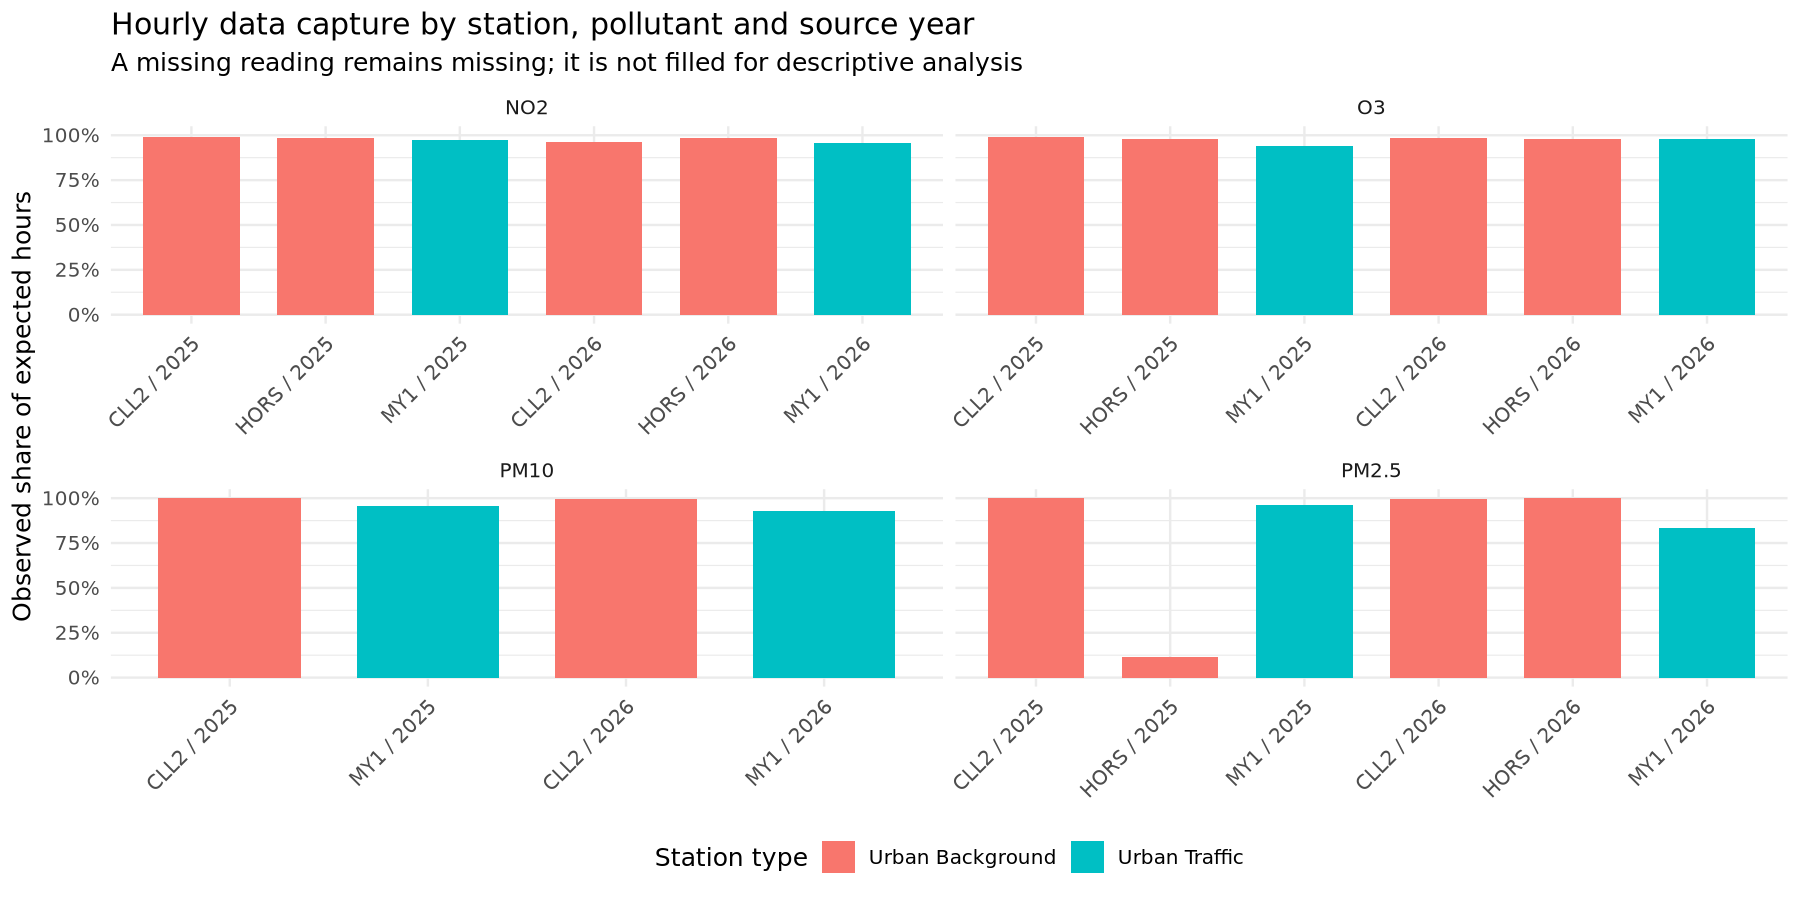

In [6]:
completeness <- hourly_panel[, .(
  expected_hours = .N,
  observed_hours = sum(observed),
  capture_pct = mean(observed) * 100,
  ratified_pct_of_observed = ifelse(
    sum(observed) == 0, NA_real_, mean(status[observed] == "R") * 100
  ),
  provisional_pct_of_observed = ifelse(
    sum(observed) == 0, NA_real_, mean(status[observed] %chin% c("P", "P*")) * 100
  )
), by = .(site_code, site_name, site_type, pollutant, year)]
print(completeness[order(pollutant, site_code, year)])

period_summary <- hourly_panel[observed == TRUE, .(
  mean = mean(value),
  median = median(value),
  p95 = quantile(value, 0.95, names = FALSE),
  maximum = max(value),
  observed_hours = .N
), by = .(site_code, site_name, site_type, pollutant, year)]
print(period_summary[order(pollutant, year, -mean)])

completeness_plot <- ggplot(
  completeness,
  aes(x = interaction(site_code, year, sep = " / "), y = capture_pct, fill = site_type)
) +
  geom_col(width = 0.72) +
  facet_wrap(~ pollutant, scales = "free_x") +
  coord_cartesian(ylim = c(0, 100)) +
  scale_y_continuous(labels = label_percent(scale = 1)) +
  labs(
    title = "Hourly data capture by station, pollutant and source year",
    subtitle = "A missing reading remains missing; it is not filled for descriptive analysis",
    x = NULL, y = "Observed share of expected hours", fill = "Station type"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "bottom")
print(completeness_plot)
ggsave(file.path(ARTIFACT_DIR, "data_completeness.png"), completeness_plot,
       width = 12, height = 6, dpi = 150)

## 6. Daily trends and WHO reference-level comparisons

site_code          site_name        site_type pollutant  year complete_days days_above_reference
       <char>             <char>           <char>    <char> <num>         <int>                <int>
 1:      CLL2  London Bloomsbury Urban Background       NO2  2025           361                  137
 2:      CLL2  London Bloomsbury Urban Background       NO2  2026           212                   68
 3:      HORS London Westminster Urban Background       NO2  2025           358                   86
 4:      HORS London Westminster Urban Background       NO2  2026           218                   33
 5:       MY1    Marylebone Road    Urban Traffic       NO2  2025           353                  235
 6:       MY1    Marylebone Road    Urban Traffic       NO2  2026           212                  106
 7:      CLL2  London Bloomsbury Urban Background      PM10  2025           365                    3
 8:      CLL2  London Bloomsbury Urban Background      PM10  2026           220                

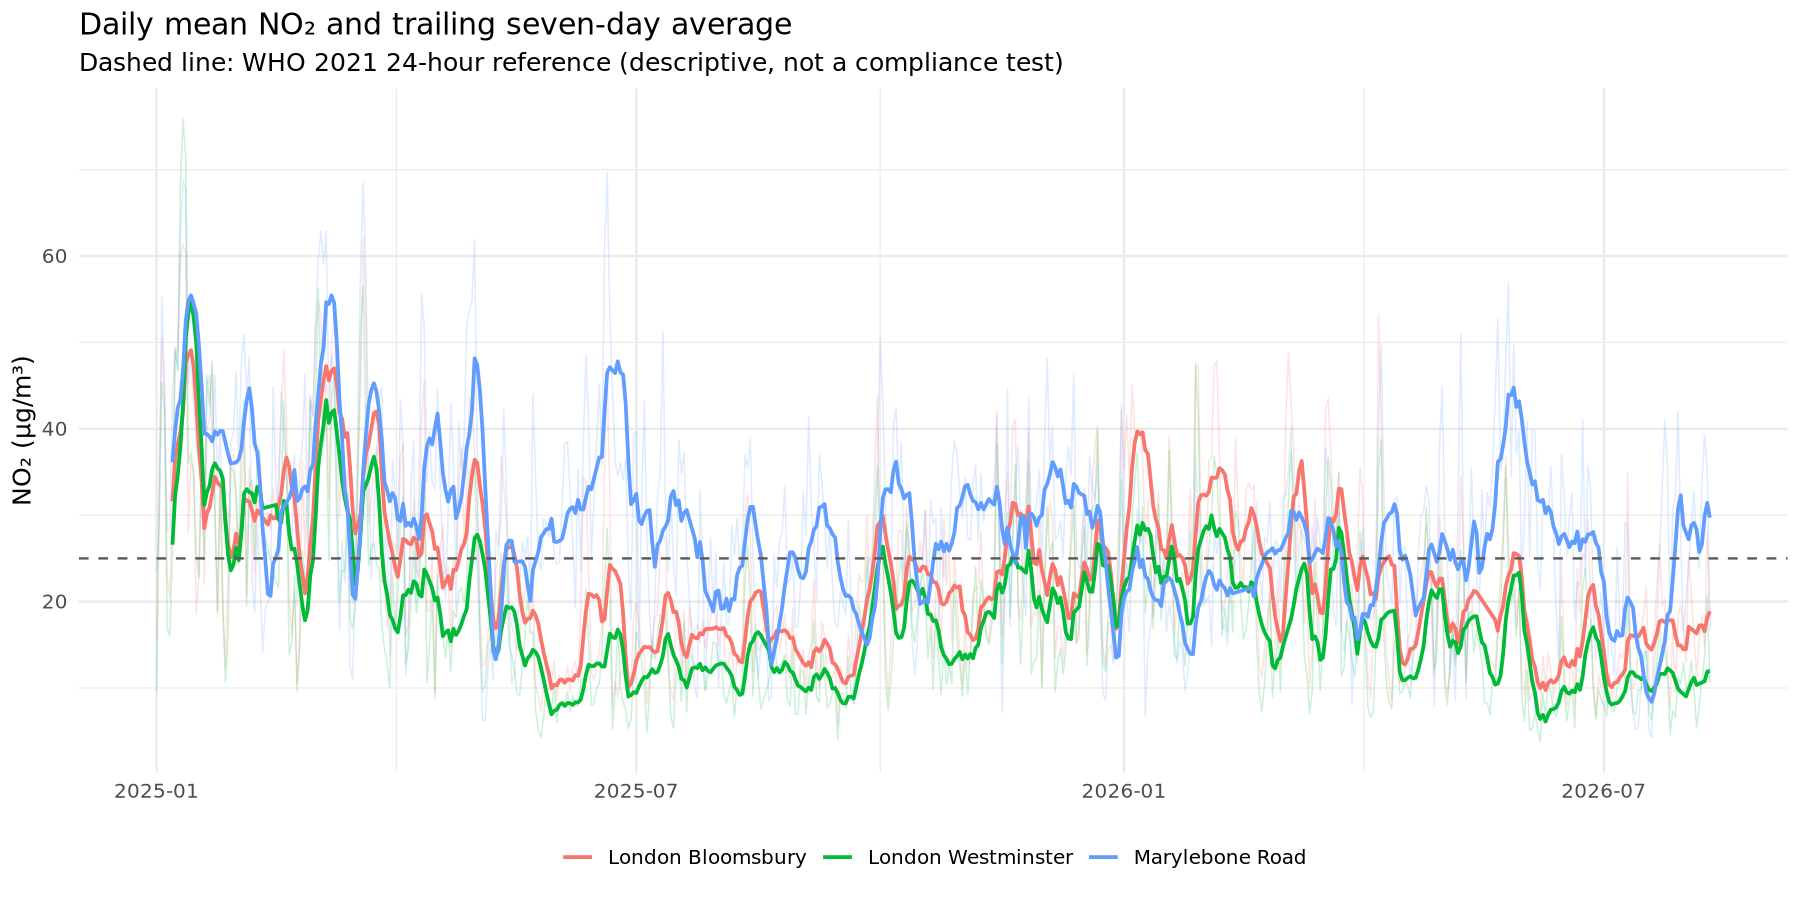

In [7]:
daily <- hourly_panel[, .(
  observed_hours = sum(observed),
  daily_mean = ifelse(sum(observed) >= 18L, mean(value, na.rm = TRUE), NA_real_),
  daily_max = ifelse(sum(observed) > 0L, max(value, na.rm = TRUE), NA_real_),
  provisional_share = ifelse(
    sum(observed) > 0L,
    mean(status[observed] %chin% c("P", "P*")), NA_real_
  )
), by = .(site_code, site_name, site_type, pollutant, period_date)]
daily[, complete_day := observed_hours >= 18L]

who_reference <- data.table(
  pollutant = c("NO2", "PM2.5", "PM10"),
  who_24h_reference = c(25, 15, 45)
)
daily <- merge(daily, who_reference, by = "pollutant", all.x = TRUE)
daily[, above_who_reference := complete_day & !is.na(who_24h_reference) &
        daily_mean > who_24h_reference]

who_summary <- daily[
  !is.na(who_24h_reference),
  .(
    complete_days = sum(complete_day),
    days_above_reference = sum(above_who_reference, na.rm = TRUE),
    share_above_reference = mean(above_who_reference[complete_day], na.rm = TRUE)
  ),
  by = .(site_code, site_name, site_type, pollutant, year = year(period_date))
]
print(who_summary[order(pollutant, site_code, year)])

daily_no2 <- daily[pollutant == "NO2" & complete_day == TRUE]
setorder(daily_no2, site_code, period_date)
daily_no2[, mean_7d := frollmean(daily_mean, 7L, align = "right", na.rm = TRUE),
          by = site_code]

trend_plot <- ggplot(daily_no2, aes(period_date, daily_mean, colour = site_name)) +
  geom_line(alpha = 0.20, linewidth = 0.35) +
  geom_line(aes(y = mean_7d), linewidth = 0.85, na.rm = TRUE) +
  geom_hline(yintercept = 25, linetype = "dashed", colour = "grey35") +
  labs(
    title = "Daily mean NO₂ and trailing seven-day average",
    subtitle = "Dashed line: WHO 2021 24-hour reference (descriptive, not a compliance test)",
    x = NULL, y = "NO₂ (µg/m³)", colour = NULL
  ) +
  theme(legend.position = "bottom")
print(trend_plot)
ggsave(file.path(ARTIFACT_DIR, "daily_no2_trend.png"), trend_plot,
       width = 12, height = 6, dpi = 150)

## 7. Roadside increment and weekday-hour pattern

paired_days mean_increment median_increment p90_increment positive_increment_share
         <int>          <num>            <num>         <num>                    <num>
1:         564          7.788            8.923         21.35                   0.7199


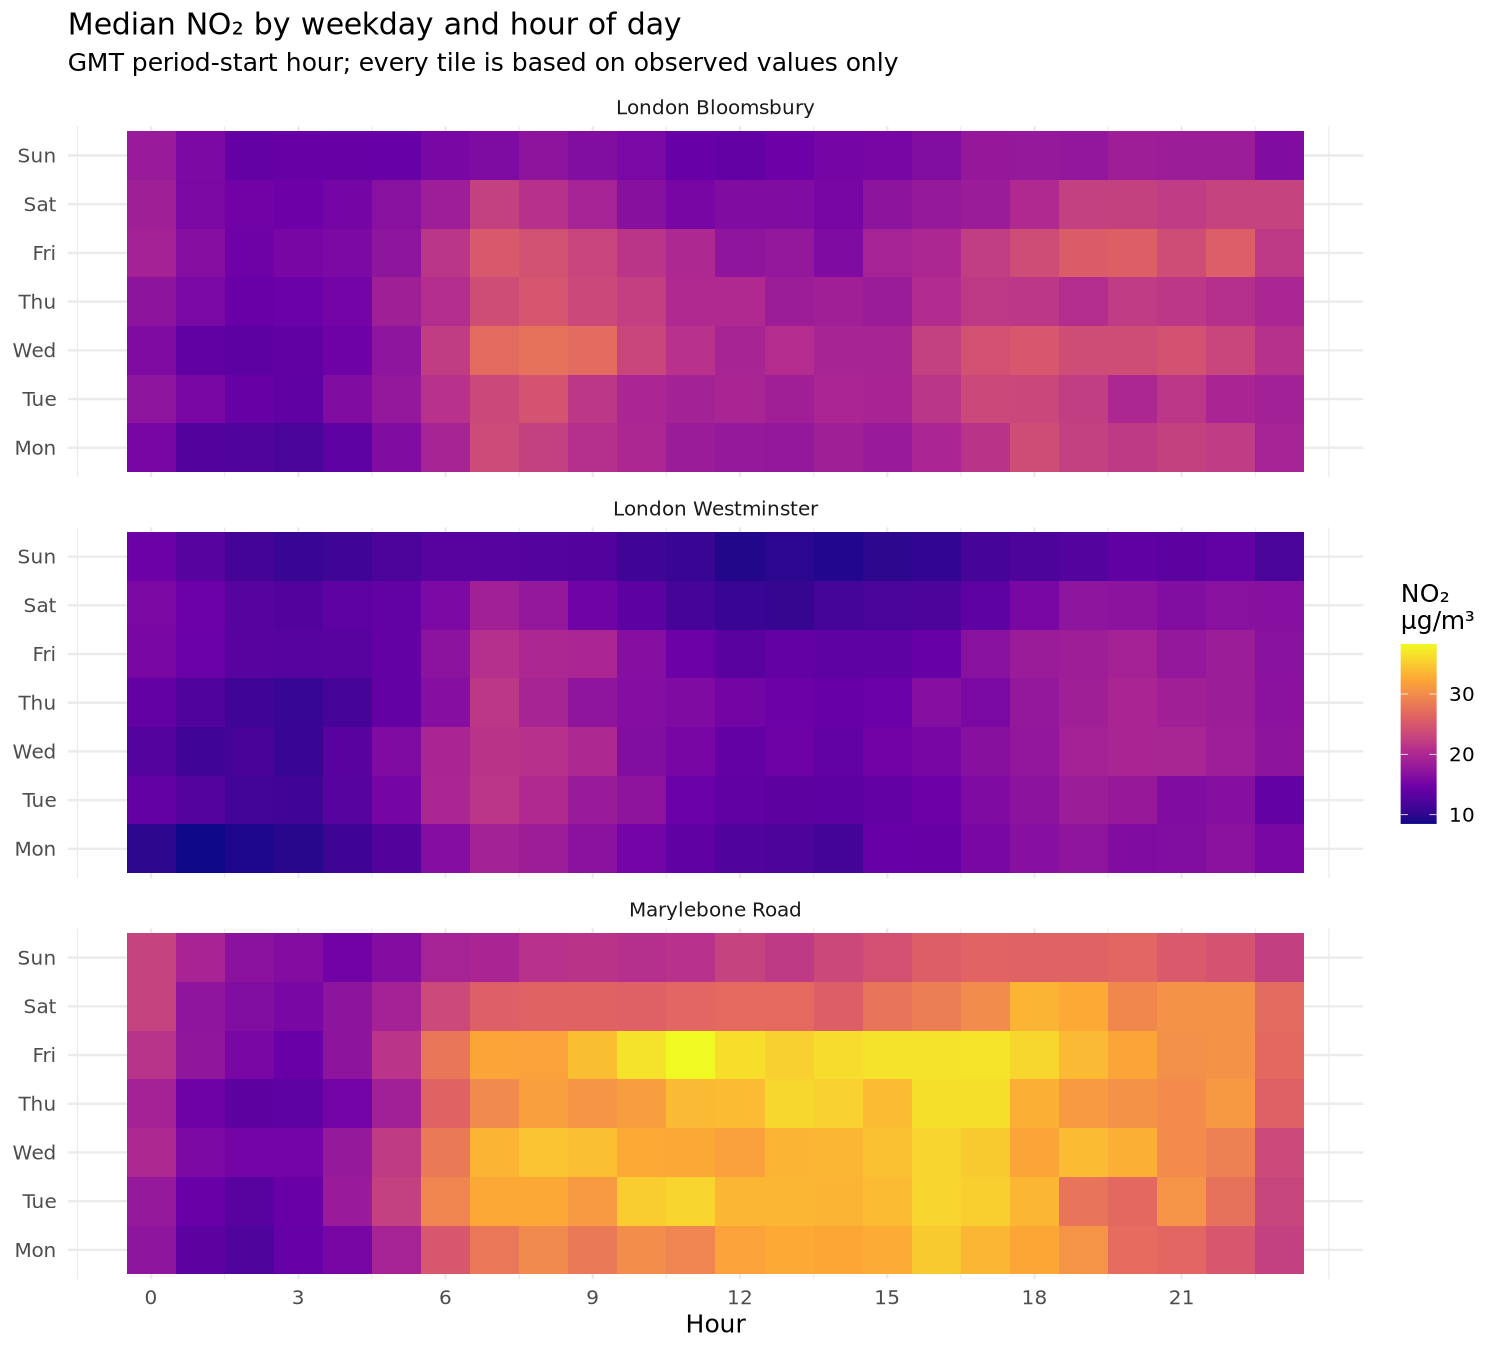

In [8]:
roadside <- daily_no2[site_code == "MY1", .(
  period_date, roadside_no2 = daily_mean
)]
background <- daily_no2[site_code %chin% c("CLL2", "HORS"), .(
  background_no2 = mean(daily_mean), background_sites = .N
), by = period_date]
roadside_comparison <- merge(roadside, background, by = "period_date")
roadside_comparison[, traffic_increment := roadside_no2 - background_no2]
traffic_summary <- roadside_comparison[, .(
  paired_days = .N,
  mean_increment = mean(traffic_increment),
  median_increment = median(traffic_increment),
  p90_increment = quantile(traffic_increment, 0.90, names = FALSE),
  positive_increment_share = mean(traffic_increment > 0)
)]
print(traffic_summary)

hourly_profile <- hourly_panel[
  pollutant == "NO2" & observed == TRUE,
  .(median_no2 = median(value), observations = .N),
  by = .(site_code, site_name, site_type, weekday, hour)
]
profile_plot <- ggplot(hourly_profile, aes(hour, weekday, fill = median_no2)) +
  geom_tile() +
  facet_wrap(~ site_name, ncol = 1) +
  scale_fill_viridis_c(option = "C") +
  scale_x_continuous(breaks = seq(0, 23, 3)) +
  labs(
    title = "Median NO₂ by weekday and hour of day",
    subtitle = "GMT period-start hour; every tile is based on observed values only",
    x = "Hour", y = NULL, fill = "NO₂\nµg/m³"
  )
print(profile_plot)
ggsave(file.path(ARTIFACT_DIR, "no2_weekday_hour_heatmap.png"), profile_plot,
       width = 10, height = 9, dpi = 150)

## 8. Leakage-safe model table and chronological split

The target is the observed hourly NO₂ concentration. Features are available at prediction time:

- station and calendar variables;
- the reading 24 hours earlier;
- the reading 168 hours earlier.

Lags are computed on the complete hourly grid **before** rows with missing targets are removed. Missing lags are filled with station medians learned only from the training period and accompanied by missingness indicators.

| Split | Period | Purpose |
|---|---|---|
| Train | Jan–Oct 2025 | Fit preprocessing and model |
| Validation | Nov–Dec 2025 | Select candidate and calibrate interval |
| Test | 2026 to latest available hour | One final untouched evaluation |

In [9]:
model_grid <- copy(hourly_panel[pollutant == "NO2"])
setorder(model_grid, site_code, timestamp)
model_grid[, lag_24 := shift(value, 24L), by = site_code]
model_grid[, lag_168 := shift(value, 168L), by = site_code]
model_data <- model_grid[observed == TRUE]
model_data[, actual := value]
model_data[, split := fcase(
  period_date <= as.Date("2025-10-31"), "train",
  period_date <= as.Date("2025-12-31"), "validation",
  period_date >= as.Date("2026-01-01"), "test",
  default = NA_character_
)]
model_data <- model_data[!is.na(split)]

lag_fill <- model_data[split == "train", .(
  lag_24_fill = median(lag_24, na.rm = TRUE),
  lag_168_fill = median(lag_168, na.rm = TRUE),
  site_train_median = median(actual)
), by = site_code]
model_data <- merge(model_data, lag_fill, by = "site_code", all.x = TRUE)
model_data[, `:=`(
  lag_24_missing = as.integer(is.na(lag_24)),
  lag_168_missing = as.integer(is.na(lag_168)),
  lag_24_imp = fifelse(is.na(lag_24), lag_24_fill, lag_24),
  lag_168_imp = fifelse(is.na(lag_168), lag_168_fill, lag_168)
)]

model_data[, site_code := factor(site_code, levels = sites$site_code)]
model_data[, weekday := factor(weekday, levels = levels(hourly_panel$weekday))]
setorder(model_data, timestamp, site_code)

split_audit <- model_data[, .(
  rows = .N,
  first_period = min(period_start),
  last_period = max(period_start),
  lag24_missing_pct = mean(lag_24_missing) * 100,
  lag168_missing_pct = mean(lag_168_missing) * 100
), by = split][match(c("train", "validation", "test"), split)]
print(split_audit)
print(lag_fill)

split  rows first_period         last_period lag24_missing_pct lag168_missing_pct
       <char> <int>       <POSc>              <POSc>             <num>              <num>
1:      train 21425   2025-01-01 2025-10-31 23:00:00            2.0163             4.2800
2: validation  4371   2025-11-01 2025-12-31 23:00:00            0.4576             0.4347
3:       test 15483   2026-01-01 2026-08-10 23:00:00            1.8149             2.9452
Key: <site_code>
   site_code lag_24_fill lag_168_fill site_train_median
      <char>       <num>        <num>             <num>
1:      CLL2       19.44        19.29             19.35
2:      HORS       15.23        15.19             15.26
3:       MY1       28.30        28.50             28.30


## 9. Honest baselines and the R generalised additive model

In [10]:
train <- model_data[split == "train"]
validation <- model_data[split == "validation"]
test <- model_data[split == "test"]

seasonal_profile <- train[, .(
  seasonal_profile = mean(actual)
), by = .(site_code, weekday, hour)]
model_data <- merge(
  model_data, seasonal_profile,
  by = c("site_code", "weekday", "hour"), all.x = TRUE, sort = FALSE
)
model_data[is.na(seasonal_profile), seasonal_profile := site_train_median]
model_data[, `:=`(
  pred_previous_day = pmax(0, lag_24_imp),
  pred_previous_week = pmax(0, lag_168_imp),
  pred_seasonal_profile = pmax(0, seasonal_profile)
)]

train <- model_data[split == "train"]
validation <- model_data[split == "validation"]
test <- model_data[split == "test"]

gam_model <- bam(
  actual ~ site_code + weekday +
    s(hour, bs = "cc", k = 12) +
    s(day_of_year, bs = "cc", k = 20) +
    s(lag_24_imp, k = 12) +
    s(lag_168_imp, k = 12) +
    lag_24_missing + lag_168_missing,
  data = train,
  method = "fREML",
  discrete = TRUE,
  knots = list(hour = c(-0.5, 23.5), day_of_year = c(0.5, 366.5))
)

model_data[, pred_gam := pmax(0, as.numeric(predict(gam_model, newdata = model_data)))]
train <- model_data[split == "train"]
validation <- model_data[split == "validation"]
test <- model_data[split == "test"]

cat(sprintf("GAM deviance explained on training data: %.1f%%\n",
            summary(gam_model)$dev.expl * 100))
print(head(tidy(gam_model, parametric = TRUE), 12))

GAM deviance explained on training data: 45.0%
# A tibble: 11 × 5
   term            estimate std.error statistic   p.value
   <chr>              <dbl>     <dbl>     <dbl>     <dbl>
 1 (Intercept)       34.7       0.240    145.   0        
 2 site_codeCLL2     -4.64      0.215    -21.6  4.81e-102
 3 site_codeHORS     -6.62      0.233    -28.5  6.04e-175
 4 weekday.L         -3.31      0.222    -14.9  8.73e- 50
 5 weekday.Q         -2.63      0.223    -11.8  5.34e- 32
 6 weekday.C         -1.06      0.219     -4.83 1.39e-  6
 7 weekday^4         -0.514     0.219     -2.35 1.89e-  2
 8 weekday^5          1.04      0.218      4.76 1.97e-  6
 9 weekday^6          0.649     0.216      3.00 2.68e-  3
10 lag_24_missing    -2.99      0.610     -4.90 9.44e-  7
11 lag_168_missing   -4.40      0.549     -8.01 1.18e- 15


## 10. Validation selection, untouched 2026 test and conformal interval

In [11]:
candidates <- list(
  "Previous day" = "pred_previous_day",
  "Previous week" = "pred_previous_week",
  "Seasonal profile" = "pred_seasonal_profile",
  "GAM" = "pred_gam"
)

metric_table <- function(frame, split_name) {
  rbindlist(lapply(names(candidates), function(model_name) {
    prediction <- frame[[candidates[[model_name]]]]
    actual <- frame$actual
    data.table(
      split = split_name,
      model = model_name,
      rows = length(actual),
      mae = mean(abs(actual - prediction)),
      rmse = sqrt(mean((actual - prediction)^2)),
      r_squared = 1 - sum((actual - prediction)^2) /
        sum((actual - mean(actual))^2),
      bias = mean(prediction - actual)
    )
  }))
}

validation_metrics <- metric_table(validation, "validation")[order(mae)]
selected_model <- validation_metrics$model[1]
selected_column <- candidates[[selected_model]]

alpha <- 0.10
validation_scores <- abs(validation$actual - validation[[selected_column]])
conformal_probability <- min(
  1, ceiling((length(validation_scores) + 1) * (1 - alpha)) /
    length(validation_scores)
)
conformal_radius <- as.numeric(quantile(
  validation_scores, probs = conformal_probability, type = 1, names = FALSE
))

test[, selected_prediction := get(selected_column)]
test[, `:=`(
  lower_90 = pmax(0, selected_prediction - conformal_radius),
  upper_90 = selected_prediction + conformal_radius
)]
interval_coverage <- test[, mean(actual >= lower_90 & actual <= upper_90)]
interval_mean_width <- test[, mean(upper_90 - lower_90)]

test_metrics <- metric_table(test, "test")[order(mae)]
metrics <- rbind(validation_metrics, test_metrics)
best_baseline_test_mae <- test_metrics[model != "GAM", min(mae)]
selected_test_mae <- test_metrics[model == selected_model, mae]
improvement_vs_best_baseline <- 100 *
  (best_baseline_test_mae - selected_test_mae) / best_baseline_test_mae

cat(sprintf("Selected on validation MAE: %s\n", selected_model))
print(validation_metrics)
print(test_metrics)
cat(sprintf(
  "90%% interval: radius %.2f µg/m³ | test coverage %.1f%% | mean width %.2f µg/m³\n",
  conformal_radius, interval_coverage * 100, interval_mean_width
))

Selected on validation MAE: Seasonal profile
        split            model  rows    mae  rmse r_squared    bias
       <char>           <char> <int>  <num> <num>     <num>   <num>
1: validation Seasonal profile  4371  9.398 11.80    0.1897  0.2113
2: validation     Previous day  4371 11.251 14.82   -0.2781 -0.3526
3: validation              GAM  4371 11.956 14.66   -0.2494  7.1100
4: validation    Previous week  4371 12.767 16.29   -0.5439  0.2061
Index: <model>
    split            model  rows    mae  rmse r_squared    bias
   <char>           <char> <int>  <num> <num>     <num>   <num>
1:   test              GAM 15483  9.662 12.50   0.13000 3.56130
2:   test     Previous day 15483  9.759 13.61  -0.03035 0.15042
3:   test Seasonal profile 15483 10.476 13.02   0.05616 3.52498
4:   test    Previous week 15483 11.608 15.80  -0.38846 0.04635
90% interval: radius 19.19 µg/m³ | test coverage 88.2% | mean width 37.89 µg/m³


## 11. Error behaviour and monitoring view

site_code          site_name        site_type  rows    mae  rmse interval_coverage mean_actual
      <fctr>             <char>           <char> <int>  <num> <num>             <num>       <num>
1:       MY1    Marylebone Road    Urban Traffic  5103 11.632 14.48            0.8103       24.80
2:      CLL2  London Bloomsbury Urban Background  5120 10.617 13.05            0.8955       21.65
3:      HORS London Westminster Urban Background  5260  9.218 11.41            0.9392       16.77
    site_code        period_start actual selected_prediction lower_90 upper_90 absolute_error outside_interval
       <fctr>              <POSc>  <num>               <num>    <num>    <num>          <num>           <lgcl>
 1:       MY1 2026-05-26 15:00:00 136.74               38.22   19.029    57.42          98.52             TRUE
 2:       MY1 2026-07-24 10:00:00 135.60               41.49   22.299    60.69          94.10             TRUE
 3:       MY1 2026-05-08 14:00:00 119.91               40.56   21.369

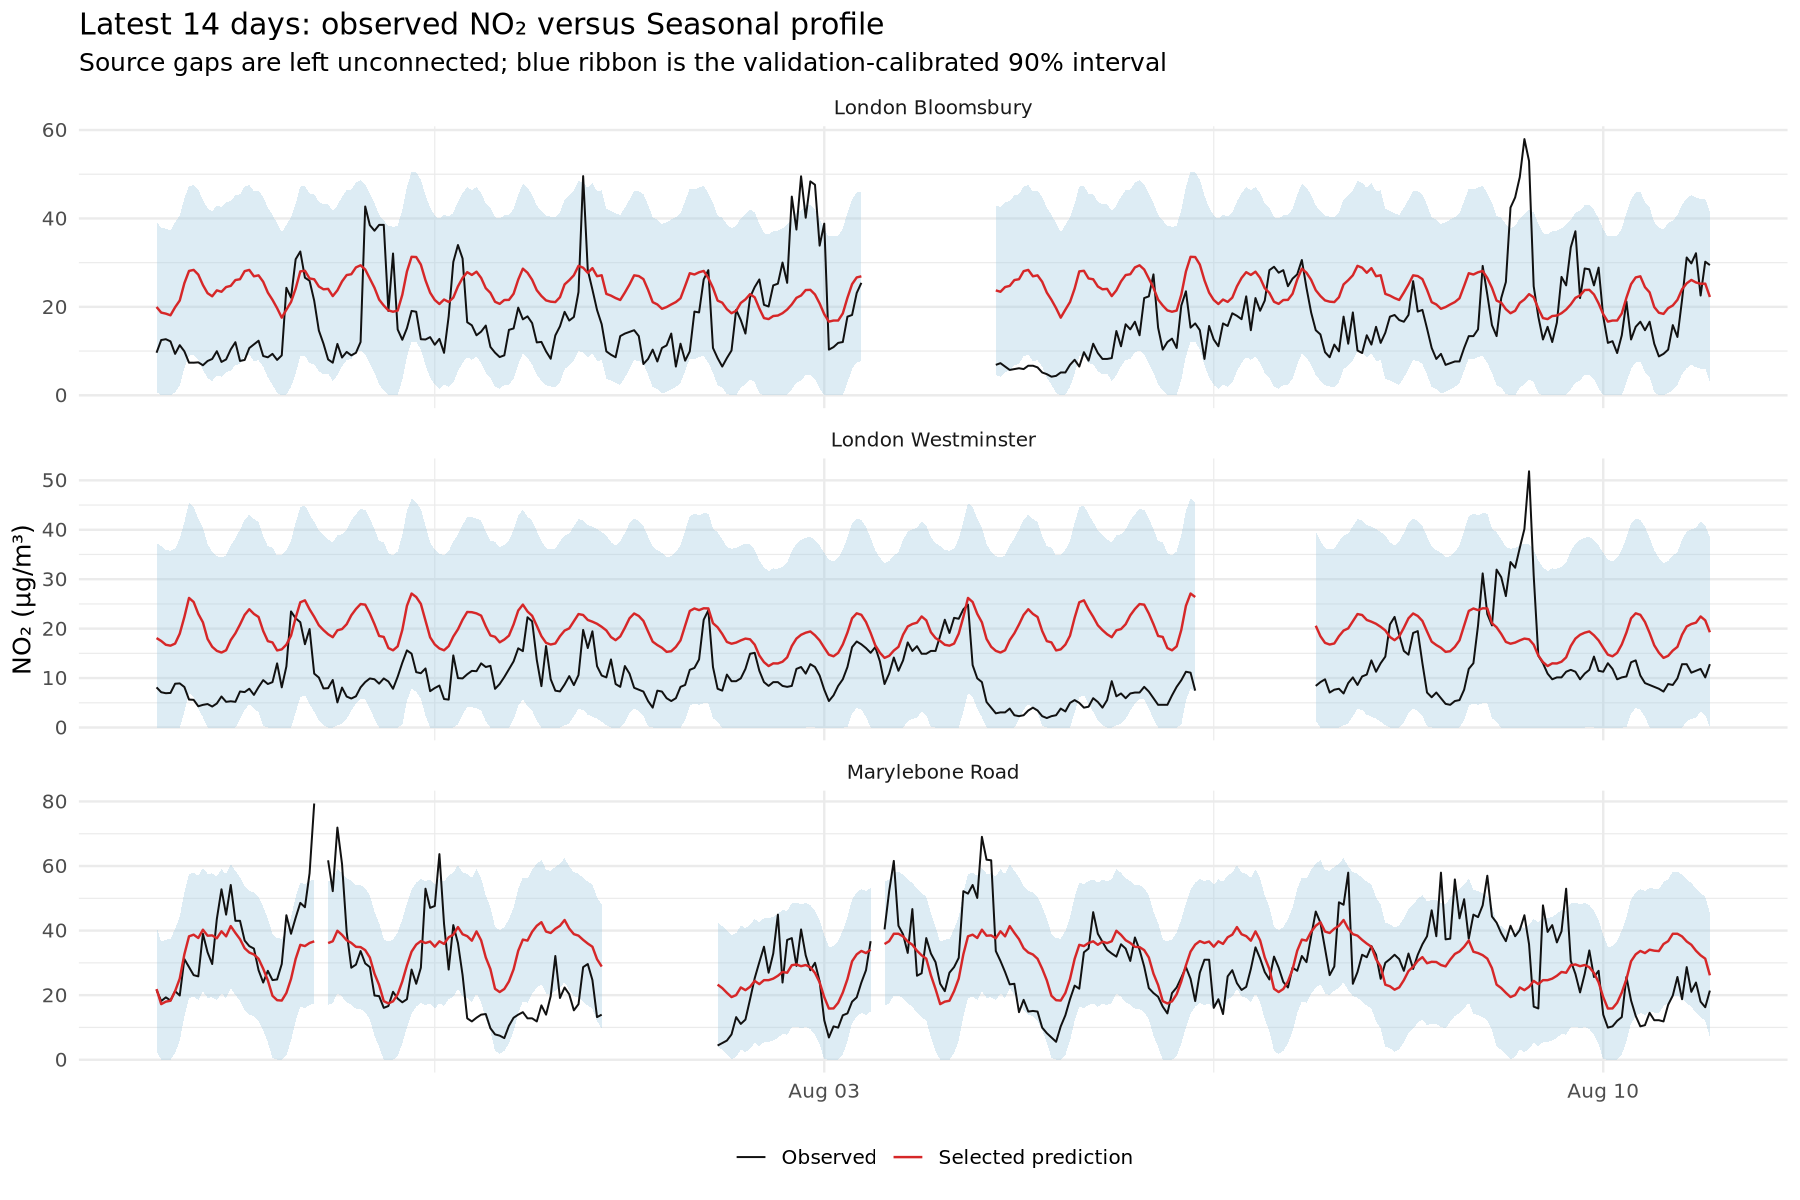

In [12]:
test[, `:=`(
  absolute_error = abs(actual - selected_prediction),
  outside_interval = actual < lower_90 | actual > upper_90
)]
error_by_site <- test[, .(
  rows = .N,
  mae = mean(absolute_error),
  rmse = sqrt(mean((actual - selected_prediction)^2)),
  interval_coverage = mean(!outside_interval),
  mean_actual = mean(actual)
), by = .(site_code, site_name, site_type)]
print(error_by_site)

latest_start <- max(test$period_date) - 13
latest_predictions <- test[period_date >= latest_start]
setorder(latest_predictions, site_code, period_start)
latest_predictions[, gap_segment := cumsum(
  is.na(shift(period_start)) |
    as.numeric(difftime(period_start, shift(period_start), units = "hours")) != 1
), by = site_code]
prediction_plot <- ggplot(
  latest_predictions,
  aes(period_start, group = interaction(site_code, gap_segment))
) +
  geom_ribbon(aes(ymin = lower_90, ymax = upper_90), fill = "#9ecae1", alpha = 0.35) +
  geom_line(aes(y = actual, colour = "Observed"), linewidth = 0.45) +
  geom_line(aes(y = selected_prediction, colour = "Selected prediction"), linewidth = 0.55) +
  facet_wrap(~ site_name, ncol = 1, scales = "free_y") +
  scale_colour_manual(values = c("Observed" = "#111111", "Selected prediction" = "#d62728")) +
  labs(
    title = sprintf("Latest 14 days: observed NO₂ versus %s", selected_model),
    subtitle = "Source gaps are left unconnected; blue ribbon is the validation-calibrated 90% interval",
    x = NULL, y = "NO₂ (µg/m³)", colour = NULL
  ) +
  theme(legend.position = "bottom")
print(prediction_plot)
ggsave(file.path(ARTIFACT_DIR, "latest_no2_predictions.png"), prediction_plot,
       width = 12, height = 8, dpi = 150)

anomaly_review <- test[order(-absolute_error), .(
  site_code, period_start, actual, selected_prediction,
  lower_90, upper_90, absolute_error, outside_interval
)][1:12]
print(anomaly_review)

## 12. Export the evidence, reload the model and run acceptance tests

In [13]:
source_manifest_path <- file.path(ARTIFACT_DIR, "source_manifest.csv")
reconciliation_path <- file.path(ARTIFACT_DIR, "cleaning_reconciliation.csv")
completeness_path <- file.path(ARTIFACT_DIR, "data_completeness.csv")
daily_path <- file.path(ARTIFACT_DIR, "daily_air_quality.csv")
metrics_path <- file.path(ARTIFACT_DIR, "model_metrics.csv")
predictions_path <- file.path(ARTIFACT_DIR, "test_predictions.csv")
model_path <- file.path(ARTIFACT_DIR, "no2_candidate_bundle.rds")

fwrite(sources, source_manifest_path)
fwrite(reconciliation, reconciliation_path)
fwrite(completeness, completeness_path)
fwrite(daily, daily_path)
fwrite(metrics, metrics_path)
fwrite(test[, .(
  site_code, site_name, site_type, period_start, actual,
  pred_previous_day, pred_previous_week, pred_seasonal_profile,
  pred_gam, selected_prediction, lower_90, upper_90, outside_interval
)], predictions_path)
candidate_bundle <- list(
  selected_model = selected_model,
  seasonal_profile = seasonal_profile,
  gam_model = gam_model
)
saveRDS(candidate_bundle, model_path)

predict_candidate <- function(bundle, new_data) {
  switch(
    bundle$selected_model,
    "GAM" = pmax(0, as.numeric(predict(bundle$gam_model, new_data))),
    "Previous day" = new_data$pred_previous_day,
    "Previous week" = new_data$pred_previous_week,
    "Seasonal profile" = new_data$pred_seasonal_profile,
    stop("Unknown candidate in persisted bundle")
  )
}
reloaded_bundle <- readRDS(model_path)
reload_sample <- test[seq_len(min(200L, .N))]
original_reload_prediction <- reload_sample$selected_prediction
restored_reload_prediction <- predict_candidate(reloaded_bundle, reload_sample)
reload_max_difference <- max(abs(
  original_reload_prediction - restored_reload_prediction
))

selected_test_row <- test_metrics[model == selected_model]
model_card <- list(
  model_name = "London hourly NO2 model",
  selected_operational_candidate = selected_model,
  persisted_artifact = basename(model_path),
  persisted_components = c(
    "selected candidate metadata", "seasonal lookup profile", "GAM benchmark"
  ),
  task = "Hourly NO2 prediction from station, calendar and past-only lag features",
  data_period = list(
    first_period = as.character(min(hourly_panel$period_start)),
    last_period = as.character(max(hourly_panel$period_start))
  ),
  development_design = list(
    train = "2025-01-01 to 2025-10-31",
    validation = "2025-11-01 to 2025-12-31",
    test = "2026-01-01 to latest available hour"
  ),
  test_metrics = as.list(selected_test_row[, .(mae, rmse, r_squared, bias)]),
  interval = list(
    nominal_coverage = 0.90,
    observed_test_coverage = interval_coverage,
    conformal_radius = conformal_radius
  ),
  intended_use = "Educational monitoring and portfolio demonstration",
  not_for = c("regulatory compliance decisions", "personal health advice", "autonomous alerts"),
  limitations = c(
    "2026 observations are provisional and may be revised",
    "No meteorology, traffic count or event features are included",
    "Three central-London stations do not represent all London neighbourhoods",
    "Prediction-interval coverage can change under future distribution shift"
  )
)
model_card_path <- file.path(ARTIFACT_DIR, "model_card.json")
writeLines(toJSON(model_card, auto_unbox = TRUE, pretty = TRUE, na = "null"), model_card_path)

# Acceptance tests: each assertion represents a release condition.
stopifnot(nrow(sources) == 6L)
stopifnot(max(hourly_panel$period_date) >= as.Date("2026-01-01"))
stopifnot(nrow(hourly_panel[, .N, by = key_columns][N > 1L]) == 0L)
stopifnot(all(is.na(hourly_panel$value) | hourly_panel$value >= 0))
stopifnot(all(hourly_panel[, diff(as.numeric(timestamp)) == 3600, by = .(site_code, pollutant)]$V1))
stopifnot(max(train$period_date) < min(validation$period_date))
stopifnot(max(validation$period_date) < min(test$period_date))
stopifnot(all(is.finite(model_data$lag_24_imp)), all(is.finite(model_data$lag_168_imp)))
stopifnot(all(is.finite(model_data$pred_gam)))
stopifnot(all(test$lower_90 <= test$selected_prediction & test$selected_prediction <= test$upper_90))
stopifnot(all(is.finite(metrics$mae)), all(is.finite(metrics$rmse)))
stopifnot(nrow(test) > 10000L)
stopifnot(reload_max_difference < 1e-10)
stopifnot(all(file.exists(c(source_manifest_path, reconciliation_path, completeness_path,
                            daily_path, metrics_path, predictions_path, model_path,
                            model_card_path))))
cat("All 14 data, leakage, prediction, interval, persistence and artifact tests passed.\n")

All 14 data, leakage, prediction, interval, persistence and artifact tests passed.


In [14]:
artifact_paths <- list.files(ARTIFACT_DIR, full.names = TRUE)
artifact_paths <- artifact_paths[basename(artifact_paths) != "release_manifest.csv"]
release_manifest <- data.table(
  artifact = basename(artifact_paths),
  bytes = file.info(artifact_paths)$size,
  sha256 = vapply(artifact_paths, digest, character(1), file = TRUE, algo = "sha256")
)
release_manifest_path <- file.path(ARTIFACT_DIR, "release_manifest.csv")
fwrite(release_manifest, release_manifest_path)
print(release_manifest[, .(artifact, bytes, sha256 = substr(sha256, 1, 16))])

artifact   bytes           sha256
                          <char>   <num>           <char>
 1:  cleaning_reconciliation.csv     255 0d6592ef9ce302db
 2:        daily_air_quality.csv  595912 c4f3980805435b87
 3:          daily_no2_trend.png  401150 9ee4c9b7bd7d1957
 4:        data_completeness.csv    2204 7d2ecbbbaf673046
 5:        data_completeness.png  101133 475039f00eaba356
 6:   latest_no2_predictions.png  309550 181f2fe18472257f
 7:              model_card.json    1297 8aa531591aef09e9
 8:            model_metrics.csv     806 8661027b38b18440
 9:     no2_candidate_bundle.rds 1104874 ac455ab75bc801d0
10: no2_weekday_hour_heatmap.png   68719 40db4b59007b2571
11:          source_manifest.csv    1749 f9c53311af91aeda
12:         test_predictions.csv 2632966 aed2c0de804bd0f6


## 13. Computed executive summary and interview-ready explanation

In [15]:
source_rows <- nrow(raw_long)
source_hours <- sum(hourly_panel$observed)
latest_date <- max(hourly_panel$period_date)
traffic_median <- traffic_summary$median_increment
test_mae <- selected_test_row$mae
test_r2 <- selected_test_row$r_squared

if (selected_model == "GAM") {
  comparison_sentence <- sprintf(
    "The GAM improved test MAE by %.1f%% versus the strongest tested baseline.",
    improvement_vs_best_baseline
  )
} else {
  gam_test_mae <- test_metrics[model == "GAM", mae]
  comparison_sentence <- sprintf(
    paste0(
      "Validation selected the %s baseline; although the GAM later recorded %.2f ug/m3 MAE on the test set, ",
      "it was not retroactively promoted using test evidence."
    ),
    selected_model, gam_test_mae
  )
}

summary_text <- sprintf(
  paste0(
    "EXECUTIVE SUMMARY\n",
    "- Parsed %s relevant pollutant records and retained %s observed station-hours through %s.\n",
    "- Median daily Marylebone-road NO2 increment versus the two background stations: %.2f ug/m3.\n",
    "- Validation-selected candidate: %s; untouched-2026 MAE %.2f ug/m3 and R-squared %.3f.\n",
    "- Validation-calibrated 90%% interval achieved %.1f%% coverage on 2026 observations.\n",
    "- %s\n",
    "- 2026 values remain provisional; all findings must be refreshed after ratification.\n"
  ),
  format(source_rows, big.mark = ",", scientific = FALSE),
  format(source_hours, big.mark = ",", scientific = FALSE),
  latest_date, traffic_median,
  selected_model, test_mae, test_r2, interval_coverage * 100,
  comparison_sentence
)
cat(summary_text)

cv_bullet <- sprintf(
  paste0(
    "Built an audited R air-quality pipeline across %s official Defra UK-AIR records from three London stations, ",
    "making missing hours and ratification status explicit; engineered past-only temporal features, benchmarked ",
    "a GAM against three baselines on a chronological 2025/2026 split, achieved %.2f ug/m3 MAE (R-squared %.3f) ",
    "on untouched 2026 data, and calibrated a 90%% interval with %.1f%% observed coverage."
  ),
  format(source_rows, big.mark = ",", scientific = FALSE),
  test_mae, test_r2, interval_coverage * 100
)
cat("\nCV BULLET\n", cv_bullet, "\n", sep = "")

EXECUTIVE SUMMARY
- Parsed 154,968 relevant pollutant records and retained 143,102 observed station-hours through 2026-08-10.
- Median daily Marylebone-road NO2 increment versus the two background stations: 8.92 ug/m3.
- Validation-selected candidate: Seasonal profile; untouched-2026 MAE 10.48 ug/m3 and R-squared 0.056.
- Validation-calibrated 90% interval achieved 88.2% coverage on 2026 observations.
- Validation selected the Seasonal profile baseline; although the GAM later recorded 9.66 ug/m3 MAE on the test set, it was not retroactively promoted using test evidence.
- 2026 values remain provisional; all findings must be refreshed after ratification.

CV BULLET
Built an audited R air-quality pipeline across 154,968 official Defra UK-AIR records from three London stations, making missing hours and ratification status explicit; engineered past-only temporal features, benchmarked a GAM against three baselines on a chronological 2025/2026 split, achieved 10.48 ug/m3 MAE (R-squared 0.056

### How to explain this project in an interview

**Problem.** Government monitoring files are current and valuable, but they are not analysis-ready: each station exposes a different wide schema, statuses repeat, missing hours are implicit and the latest year is provisional.

**Cleaning decision.** I separated source acquisition, parsed observations and the complete hourly panel. I kept ratification status, fingerprinted every file, made absent hours explicit and never filled gaps in the descriptive air-quality results.

**Preprocessing decision.** For prediction, I created exact 24-hour and 168-hour lags on the complete grid. Only lag features—not targets—were imputed, using medians learned from the training period. That avoids both future leakage and false measurements.

**Evaluation decision.** I trained on January–October 2025, selected the operational candidate on November–December 2025, calibrated uncertainty on those validation residuals, and opened 2026 once for final testing. The notebook promotes a baseline if it wins; it does not force the complex model to look better.

**Production thinking.** The release includes source hashes, a cleaning reconciliation, station-level error analysis, a reload-tested R model, prediction intervals, a model card and a SHA-256 artifact manifest. The main remaining gaps are weather, traffic/event features and broader geographic coverage.